# EMRI: WDM time-frequency map + FEW frequency evolution overplot

In [56]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors

from WDMWaveletTransforms.wavelet_transforms import transform_wavelet_time
from few.trajectory.inspiral import EMRIInspiral, get_fundamental_frequencies, MTSUN_SI
from few.waveform import GenerateEMRIWaveform

In [61]:
# Physical constants
G = 6.674080e-11
c = 299792458.
MSUN = 1.98848e30

def Keplerian_p_from_f(M, mu, f_orb_0, e0):
    return c**2 * (1 - e0**2) / (2 * np.pi * f_orb_0 * G * (M + mu) * MSUN)**(2/3)

# System parameters
M = 1134944.869275098
m = 29.489999547765798
f1_measured = 0.001380463140752472
e0 = 0.22865665220266215
a = 0.5
p0 = Keplerian_p_from_f(M, m, f1_measured, e0)
Y0 = 1.0
Phi_phi0, Phi_theta0, Phi_r0 = 0., 1.2, 3.5

# Extrinsic params
qS, phiS, qK, phiK = 0.2, 0.2, 0.8, 0.8
dist = 5.235888314207546

dt = 10.0
T  = 1  # years

In [62]:
wave_gen = GenerateEMRIWaveform('Pn5AAKWaveform')

# Trajectory for fundamental frequencies
traj = EMRIInspiral(func='PN5')
t, p, e, x, _, _, _ = traj(
    M, m, a, p0, e0, Y0,
    Phi_phi0=Phi_phi0, Phi_theta0=Phi_theta0, Phi_r0=Phi_r0,
    dt=dt, T=T, upsample=True, fix_t=True
)

# GW waveform (phases are positional in few 2.0)
h = np.real(wave_gen(
    M, m, a, p0, e0, Y0,
    qS, phiS, qK, phiK, dist,
    Phi_phi0, Phi_theta0, Phi_r0,
    mich=False, dt=dt, T=T
)).astype(np.float64)

print(f"h length: {len(h)}, traj length: {len(t)}, h max: {np.abs(h).max():.3e}")

h length: 659369, traj length: 659398, h max: 4.852e-21


In [63]:
# Fundamental frequencies as a function of time [Hz]
OmegaPhi, OmegaTheta, OmegaR = get_fundamental_frequencies(a, p, e, x)
scale = 1.0 / (M * MTSUN_SI) / (2 * np.pi)

fPhi   = OmegaPhi   * scale
fTheta = OmegaTheta * scale
fR     = OmegaR     * scale

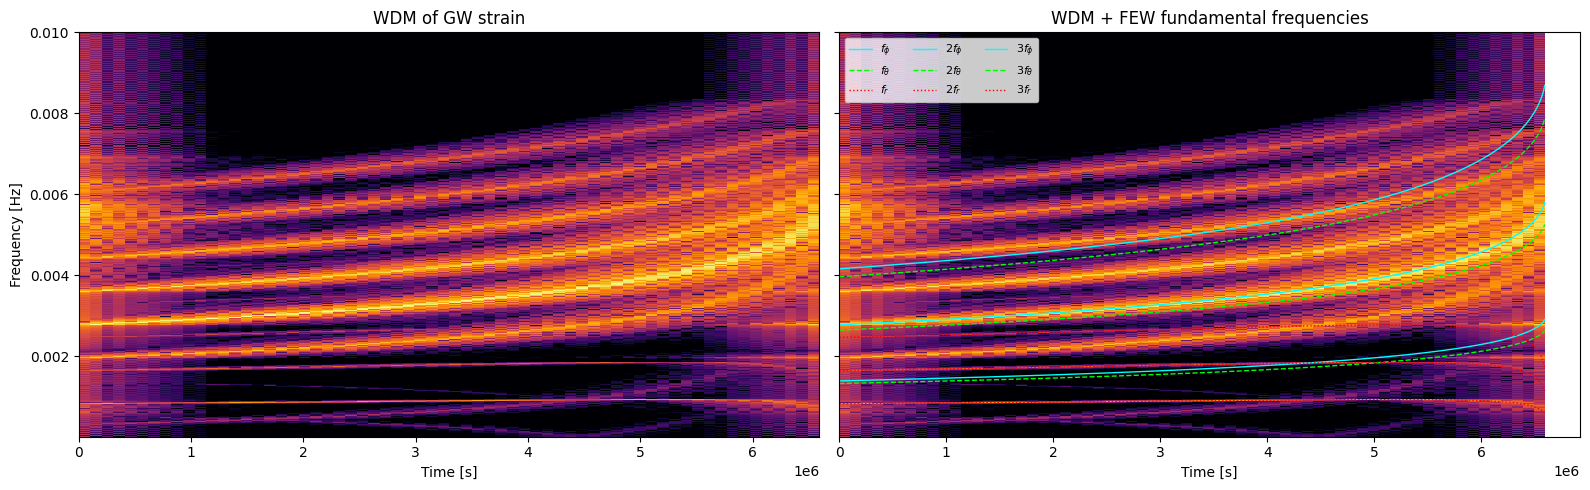

In [72]:
from matplotlib import colors

def wavelet_specgram(ax, t, f, pz, fmax=np.inf, vmin=None, vmax=None, log=True):
    Nt = len(t)
    Nf = len(f)
    e = np.argmin(np.abs(f - fmax)) if fmax < np.inf else Nf - 1
    z = pz[:, :e].copy()
    z /= z.max()
    vmin = vmin or z[z > 0].min()
    vmax = vmax or z.max()
    norm = colors.LogNorm(vmin=vmin, vmax=vmax) if log else colors.Normalize(vmin=vmin, vmax=vmax)
    z_clean = np.clip(z, vmin, vmax)
    ax.pcolormesh(t, f[:e+1], z_clean.reshape((Nt-1, e)).T,
                  cmap='inferno', norm=norm, shading='auto', rasterized=True)

def scalogram(ax, data_col, dt, fmult=1, Nt=64, vmin=None, log=True):
    Nf = len(data_col) // Nt
    ND = Nf * Nt
    Tobs = ND * dt
    wt = np.linspace(0, Tobs, Nt + 1)
    wf = np.arange(0, Nf + 1) / (2 * dt * Nf)
    aa = transform_wavelet_time(data_col[:ND], Nf, Nt)
    wavelet_specgram(ax, wt, wf * fmult, np.abs(aa), vmin=vmin, log=log)
    return wt, wf * fmult

# --- WDM transform ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

wt, wf = scalogram(axes[0], h, dt, log=True, vmin=1e-6)
axes[0].set_xlabel('Time [s]')
axes[0].set_ylabel('Frequency [Hz]')
axes[0].set_title('WDM of GW strain')
#axes[0].set_yscale('log')

scalogram(axes[1], h, dt, log=True, vmin=1e-6)
axes[1].set_xlabel('Time [s]')
axes[1].set_title('WDM + FEW fundamental frequencies')
#axes[1].set_yscale('log')

# Overplot harmonics
cmap_lines = {'phi': 'cyan', 'theta': 'lime', 'r': 'red'}
for n in range(1, 4):
    axes[1].plot(t, n * fPhi,   color=cmap_lines['phi'],   lw=1, ls='-',
                 label=f'$f_\\phi$' if n==1 else f'${n}f_\\phi$')
    axes[1].plot(t, n * fTheta, color=cmap_lines['theta'], lw=1, ls='--',
                 label=f'$f_\\theta$' if n==1 else f'${n}f_\\theta$')
    axes[1].plot(t, n * fR,     color=cmap_lines['r'],     lw=1, ls=':',
                 label=f'$f_r$' if n==1 else f'${n}f_r$')

axes[1].set_ylim(wf[1], wf[-1])
axes[1].set_ylim(wf[1], 0.01)
axes[1].legend(fontsize=8, ncol=3, loc='upper left')
plt.tight_layout()
plt.show()